# Часть 1

## Этап 1

In [1]:
import os
import numpy as np
import pandas as pd

import mlflow
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from dotenv import load_dotenv
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import roc_auc_score

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import confint_proportions_2indep

from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

from causalml.inference.meta import BaseTRegressor, BaseXRegressor, BaseRRegressor

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5001
MLFLOW_TRACKING_URI = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net")

EXPERIMENT_NAME_STAGE_3 = "UPLIFT_STAGE_3_MODEL_COMPARE"
EXPERIMENT_NAME_STAGE_4 = "UPLIFT_STAGE_4_TUNING"

ASSETS_DIR = PROJECT_ROOT / "assets_uplift"
STAGE3_DIR = ASSETS_DIR / "stage3_model_compare"
STAGE4_DIR = ASSETS_DIR / "stage4_tuning"

for stage_dir in [STAGE3_DIR, STAGE4_DIR]:
    stage_dir.mkdir(parents=True, exist_ok=True)


def init_mlflow(experiment_name: str) -> None:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_registry_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(experiment_name)

In [3]:
df = pd.read_csv('uplift_fp_data.csv')

print(f"shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"\nindex: {type(df.index).__name__} | unique={df.index.is_unique} | monotonic={df.index.is_monotonic_increasing}")
print(df.info())
display(df.head(5))

shape: 64,000 x 10

index: RangeIndex | unique=True | monotonic=True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB
None


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


## Этап 2

### EDA


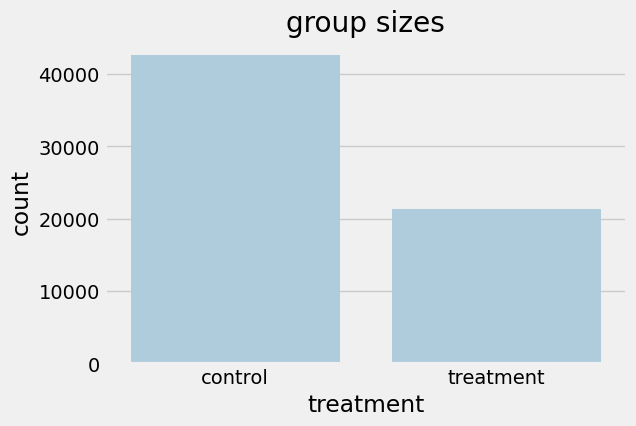

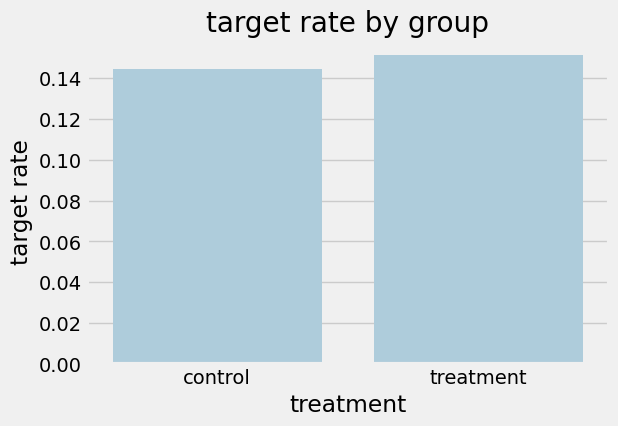

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="treatment")
plt.title("group sizes")
plt.xticks([0, 1], ["control", "treatment"])
plt.xlabel("treatment")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="treatment", y="target", errorbar=None)
plt.title("target rate by group")
plt.xticks([0, 1], ["control", "treatment"])
plt.xlabel("treatment")
plt.ylabel("target rate")
plt.show()

In [5]:
control = df[df["treatment"] == 0]
treat = df[df["treatment"] == 1]

n_control = int(len(control))
n_treat = int(len(treat))

x_control = int(control["target"].sum())
x_treat = int(treat["target"].sum())

p_control = x_control / n_control
p_treat = x_treat / n_treat
uplift = p_treat - p_control

print(f"control size: {n_control:,}")
print(f"treatment size: {n_treat:,}")
print(f"control rate: {p_control:.6f} ({x_control}/{n_control})")
print(f"treatment rate: {p_treat:.6f} ({x_treat}/{n_treat})")
print(f"uplift (diff in rates): {uplift:.6f}")

cont = pd.DataFrame(
    {0: [n_control - x_control, n_treat - x_treat], 1: [x_control, x_treat]},
    index=pd.Index([0, 1], name="treatment")
)
cont.columns.name = "target"

print("contingency table:")
print(cont.to_string())

control size: 42,613
treatment size: 21,387
control rate: 0.144463 (6156/42613)
treatment rate: 0.151400 (3238/21387)
uplift (diff in rates): 0.006937
contingency table:
target         0     1
treatment             
0          36457  6156
1          18149  3238


**EDA SUMMERY**
Since both treatment and target variables are binary, the appropriate statistical method is the chi-square test of independence. 

p-value < 0.05
we reject the null hypothesis and conclude that treatment has a statistically significant effect on the target variable.

# Этап 2

### Проверка на статистическую значимость

In [6]:
chi2, p_value, dof, expected = chi2_contingency(cont)
min_expected = float(np.min(expected))

print(f"chi2 p-value: {p_value:.4g}")
print(f"min expected cell count: {min_expected:.3f}")

ci_low, ci_high = confint_proportions_2indep(
    count1=x_treat, nobs1=n_treat,
    count2=x_control, nobs2=n_control,
    method="score"
)

print(f"uplift 95% ci: [{ci_low:.4f}, {ci_high:.4f}]")

chi2 p-value: 0.01994
min expected cell count: 3139.211
uplift 95% ci: [0.0011, 0.0128]


**Test choice justification**

`treatment` and `target` are binary variables, so the task is to compare the success rates (target=1) between two independent groups (control vs treatment).  
Therefore we use a 2×2 contingency table and apply the chi-square test of independence to test whether `target` depends on `treatment`.

The chi-square test is appropriate when expected cell counts are sufficiently large (rule of thumb: ≥ 5). In our data the minimum expected cell count is well above this threshold, so the chi-square approximation is valid.

## Построение корреляций

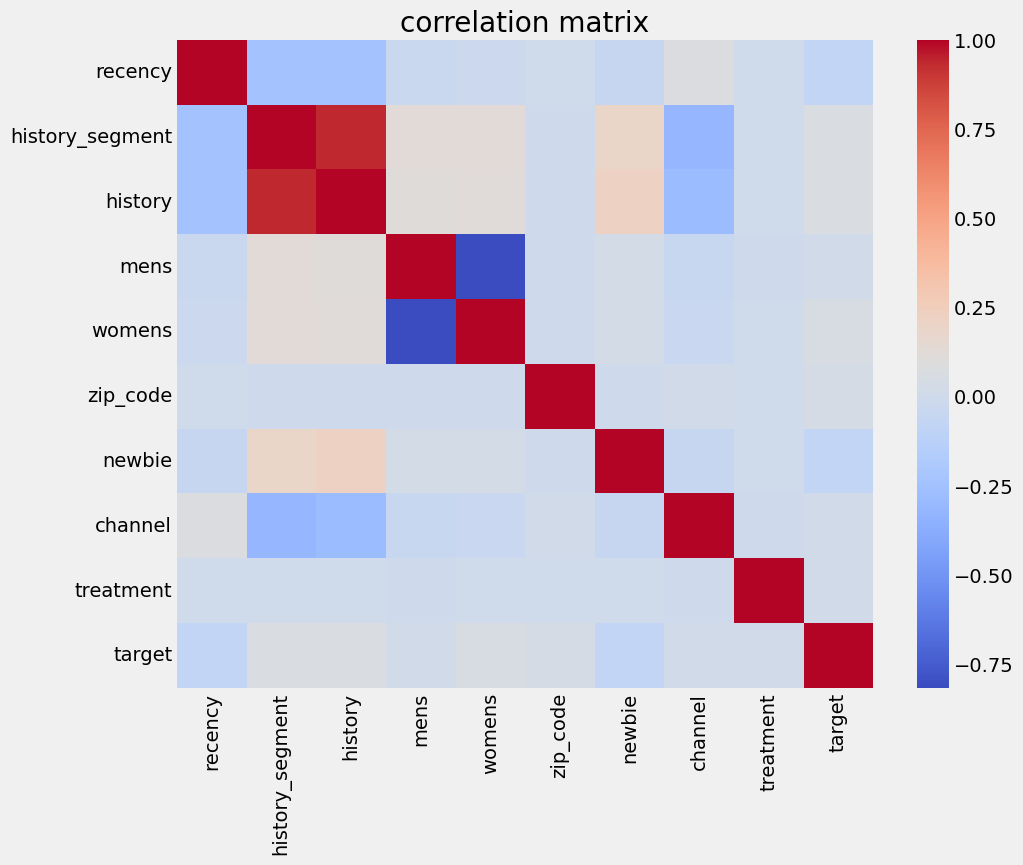

top correlations with target:
target             1.000000
history_segment    0.069734
history            0.065153
womens             0.051999
zip_code           0.037570
channel            0.010584
treatment          0.009247
mens               0.006712
newbie            -0.073924
recency           -0.074765


In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("correlation matrix")
plt.show()

corr_with_target = corr_matrix["target"].sort_values(ascending=False)
print("top correlations with target:")
print(corr_with_target.head(10).to_string())

The correlations with the target are generally weak (all absolute values are below 0.1), which means no single feature has a strong linear relationship with the target. The strongest positive correlations are history_segment, history, and womens, while the strongest negative correlations are recency and newbie, but all of them are still relatively small.

## Этап 3

In [8]:
feature_names = [c for c in df.columns if c not in ["target", "treatment"]]
categorical_features = [c for c in ["zip_code", "channel", "history_segment"] if c in feature_names]
numeric_features = [c for c in feature_names if c not in categorical_features]

def calc_smd(control_series: pd.Series, treat_series: pd.Series) -> float:
    pooled_std = np.sqrt((float(control_series.var(ddof=1)) + float(treat_series.var(ddof=1))) / 2)
    if pooled_std == 0:
        return 0.0
    return float((float(treat_series.mean()) - float(control_series.mean())) / pooled_std)

def calc_cramers_v(table_2d: pd.DataFrame) -> float:
    chi2_local, _, _, _ = chi2_contingency(table_2d)
    n = int(table_2d.to_numpy().sum())
    rows, cols = table_2d.shape
    k = min(rows, cols)
    if n == 0 or k <= 1:
        return 0.0
    return float(np.sqrt(chi2_local / (n * (k - 1))))

balance_rows = []

for col in numeric_features:
    balance_rows.append({"feature": col, "metric": "smd", "value": abs(calc_smd(control[col], treat[col]))})

for col in categorical_features:
    contingency_table = pd.crosstab(df["treatment"], df[col])
    balance_rows.append({"feature": col, "metric": "cramers_v", "value": calc_cramers_v(contingency_table)})

balance = pd.DataFrame(balance_rows).sort_values("value", ascending=False)

print("top imbalance signals:")
print(balance.head(10).to_string(index=False))

smd_bad_count = int(((balance["metric"] == "smd") & (balance["value"] >= 0.1)).sum())
v_bad_count = int(((balance["metric"] == "cramers_v") & (balance["value"] >= 0.05)).sum())

print(f"features with |smd| >= 0.1: {smd_bad_count}")
print(f"categorical with v >= 0.05: {v_bad_count}")

top imbalance signals:
        feature    metric    value
history_segment cramers_v 0.009459
           mens       smd 0.006339
        channel cramers_v 0.006041
         newbie       smd 0.003003
        history       smd 0.002646
       zip_code cramers_v 0.002322
        recency       smd 0.001762
         womens       smd 0.001152
features with |smd| >= 0.1: 0
categorical with v >= 0.05: 0


In [9]:
X_prop = df[feature_names].copy()
t_prop = df["treatment"].astype(int)

X_prop_train, X_prop_valid, t_prop_train, t_prop_valid = train_test_split(
    X_prop, t_prop, test_size=0.2, random_state=42, stratify=t_prop
)

propensity_model = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
propensity_model.fit(X_prop_train, t_prop_train)

t_prop_score = propensity_model.predict_proba(X_prop_valid)[:, 1]
propensity_auc = roc_auc_score(t_prop_valid, t_prop_score)

print(f"propensity auc: {propensity_auc:.4f}")

propensity auc: 0.5012


**model choice**
- smd for numeric features is below 0.1 and cramér’s v for categorical-like features is below 0.05, so groups look balanced.
- this suggests treatment assignment is close to random (ab-like), so i do not rely on propensity-heavy approaches.
- i compare three models from the list:
  1) t-learner as a strong and simple baseline,
  2) x-learner as a strong option when group sizes differ (here ~2:1),
  3) uplift trees to directly optimize segmentation by treatment effect.

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [10]:
X = df.drop(columns=["target", "treatment"])
y = df["target"].astype(int)
treatment = df["treatment"].astype(int)

stratify_key = treatment.astype(str) + "_" + y.astype(str)

X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X, y, treatment,
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

print(f"train size: {X_train.shape[0]:,}")
print(f"test size: {X_test.shape[0]:,}")

treatment_mapping = {0: "control", 1: "treatment"}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

train size: 51,200
test size: 12,800


In [11]:
base_params = {
    "n_estimators": 500,
    "min_samples_leaf": 50,
    "random_state": 42,
    "n_jobs": -1
}

def make_base_regressor() -> RandomForestRegressor:
    return RandomForestRegressor(**base_params)

def compute_metrics(model_name: str, uplift_pred: np.ndarray) -> dict:
    uplift_pred = np.asarray(uplift_pred).squeeze()
    return {
        "uplift_auc": float(uplift_auc_score(y_test, uplift_pred, treatment_test)),
        "qini_auc": float(qini_auc_score(y_test, uplift_pred, treatment_test)),
        "uplift_at_30": float(uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy="overall")),
        "propensity_auc": float(propensity_auc)
    }

### Обучение выбранного бейзлайна

In [12]:
t_learner = BaseTRegressor(learner=make_base_regressor(), control_name=0)
t_learner.fit(X_train.values, treatment_train.values, y_train.values)

t_pred = t_learner.predict(X_test.values).squeeze()

### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [13]:
t_metrics = compute_metrics("t_learner_baseline", t_pred)
print("baseline metrics:")
print(pd.DataFrame([t_metrics]).to_string(index=False))

baseline metrics:
 uplift_auc  qini_auc  uplift_at_30  propensity_auc
   0.025543  0.058554      0.050924        0.501162


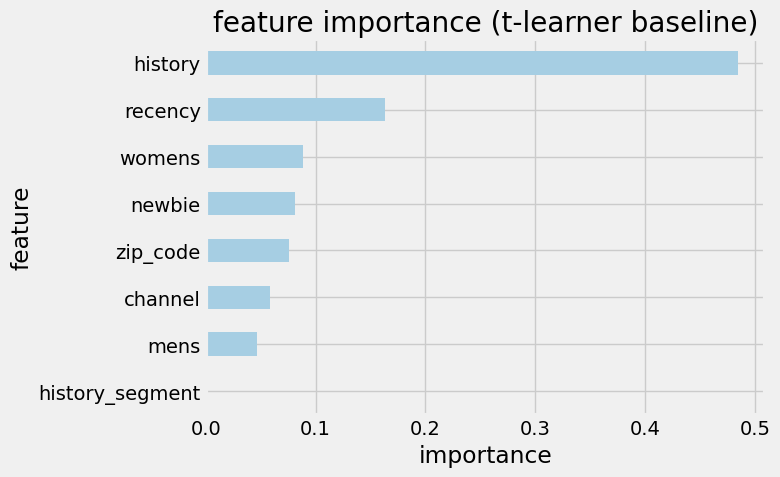

In [14]:
treatment_group = 1

control_model = t_learner.models_c[treatment_group]
treat_model = t_learner.models_t[treatment_group]

importance_mean = (control_model.feature_importances_ + treat_model.feature_importances_) / 2
importance = pd.Series(importance_mean, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.head(15).sort_values().plot(kind="barh")
plt.title("feature importance (t-learner baseline)")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.show()

# Обучение 2 моделей 

### Обучение модели 1

In [15]:
x_learner = BaseXRegressor(learner=make_base_regressor(), control_name=0)
x_learner.fit(X_train.values, treatment_train.values, y_train.values)

x_pred = x_learner.predict(X_test.values).squeeze()
print("x-learner trained")

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

x-learner trained


### Получение метрик по модели 1

In [16]:
x_metrics = compute_metrics("x_learner", x_pred)
print("model 1 metrics:")
print(pd.DataFrame([x_metrics]).to_string(index=False))

model 1 metrics:
 uplift_auc  qini_auc  uplift_at_30  propensity_auc
    0.02984  0.066771      0.052519        0.501162


### Обучение модели 2

In [17]:
r_learner = BaseRRegressor(
    learner=make_base_regressor(),
    control_name=0, n_fold=5,
    random_state=42
)

r_learner.fit(X_train.values, treatment_train.values, y_train.values, p=None, verbose=False)

r_pred = r_learner.predict(X_test.values).squeeze()
print("r-learner trained")

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

r-learner trained


### Получение метрик по модели 2

In [18]:
r_metrics = compute_metrics("r_learner", r_pred)
print("model 2 metrics:")
print(pd.DataFrame([r_metrics]).to_string(index=False))

model 2 metrics:
 uplift_auc  qini_auc  uplift_at_30  propensity_auc
   0.023076   0.05133       0.03322        0.501162


In [19]:
results = pd.DataFrame([t_metrics, x_metrics, r_metrics]).sort_values(
    by=["uplift_at_30", "qini_auc", "uplift_auc"],
    ascending=False
)

print("model comparison:")
print(results.to_string(index=False))

model comparison:
 uplift_auc  qini_auc  uplift_at_30  propensity_auc
   0.029840  0.066771      0.052519        0.501162
   0.025543  0.058554      0.050924        0.501162
   0.023076  0.051330      0.033220        0.501162


**model selection**
- main metric: uplift@30% because it reflects targeting quality for the top 30% users.
- qini auc and uplift auc are used as sanity checks for overall ranking quality.
- final choice: the model with the best uplift@30% while keeping qini/uplift auc competitive and stable.

In [21]:
init_mlflow(EXPERIMENT_NAME_STAGE_3)

comparison_path = STAGE3_DIR / "model_comparison.csv"
balance_path = STAGE3_DIR / "balance_top10.csv"
importance_path = STAGE3_DIR / "feature_importance_t_learner.png"

results.to_csv(comparison_path, index=False)
balance.head(10).to_csv(balance_path, index=False)

plt.figure(figsize=(8, 5))
importance.head(15).sort_values().plot(kind="barh")
plt.title("feature importance (t-learner baseline)")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
plt.savefig(importance_path, dpi=150)
plt.close()

def log_stage3_run(run_name: str, model_obj, uplift_pred: np.ndarray) -> None:
    metrics = compute_metrics(run_name, uplift_pred)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(base_params)
        mlflow.log_metrics(metrics)
        mlflow.log_metric("propensity_auc", float(propensity_auc))

        mlflow.log_artifact(str(comparison_path))
        mlflow.log_artifact(str(balance_path))
        mlflow.log_artifact(str(importance_path))

        model_path = STAGE3_DIR / f"{run_name}.joblib"
        joblib.dump(model_obj, model_path)
        mlflow.log_artifact(str(model_path))

        print(f"mlflow logged: {run_name}")


log_stage3_run("t_learner_baseline", t_learner, t_pred)
log_stage3_run("x_learner", x_learner, x_pred)
log_stage3_run("r_learner", r_learner, r_pred)

mlflow logged: t_learner_baseline
🏃 View run t_learner_baseline at: http://127.0.0.1:5001/#/experiments/16/runs/38857a7e94ae4cf28279353d958d9068
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/16
mlflow logged: x_learner
🏃 View run x_learner at: http://127.0.0.1:5001/#/experiments/16/runs/5314070f8d0940e5b99bfade6eb4301f
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/16
mlflow logged: r_learner
🏃 View run r_learner at: http://127.0.0.1:5001/#/experiments/16/runs/9b39d246f0ec4c708e0bcd3bda2b427b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/16


# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

In [22]:
X_train_fe = pd.get_dummies(X_train, columns=categorical_features)
X_test_fe = pd.get_dummies(X_test, columns=categorical_features)

X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

print(f"train fe shape: {X_train_fe.shape}")
print(f"test fe shape: {X_test_fe.shape}")

ohe_feature_columns = X_train_fe.columns.tolist()

train fe shape: (51200, 18)
test fe shape: (12800, 18)


#### Генерация признаков (опционально)

In [23]:
def add_feature_engineering(X: pd.DataFrame) -> pd.DataFrame:
    X_new = X.copy()

    X_new["history_log"] = np.log1p(X_new["history"])
    X_new["history_per_recency"] = X_new["history"] / (X_new["recency"] + 1.0)
    X_new["history_x_newbie"] = X_new["history"] * X_new["newbie"]
    X_new["history_x_mens"] = X_new["history"] * X_new["mens"]
    X_new["history_x_womens"] = X_new["history"] * X_new["womens"]

    return X_new


X_train_eng = add_feature_engineering(X_train)
X_test_eng = add_feature_engineering(X_test)

X_train_fe = pd.get_dummies(X_train_eng, columns=categorical_features)
X_test_fe = pd.get_dummies(X_test_eng, columns=categorical_features)
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

ohe_feature_columns = X_train_fe.columns.tolist()

print(f"train fe shape: {X_train_fe.shape}")
print(f"test fe shape:  {X_test_fe.shape}")
print(f"added numeric features: 5")

train fe shape: (51200, 23)
test fe shape:  (12800, 23)
added numeric features: 5


### Подбор гиперпараметров

In [24]:
X_tr, X_val, y_tr, y_val, treatment_tr, treatment_val = train_test_split(
    X_train_fe,
    y_train,
    treatment_train,
    test_size=0.25,
    random_state=42,
    stratify=treatment_train.astype(str) + "_" + y_train.astype(str)
)

print(f"train for tuning: {X_tr.shape[0]:,}")
print(f"valid for tuning: {X_val.shape[0]:,}")

def objective(trial: optuna.Trial) -> float:
    tuned_regressor = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 25),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 400),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        random_state=42,
        n_jobs=-1
    )

    model = BaseXRegressor(learner=tuned_regressor, control_name=0)
    model.fit(X_tr.values, treatment_tr.values, y_tr.values)

    uplift_pred_val = np.asarray(model.predict(X_val.values)).squeeze()

    score = uplift_at_k(y_val, uplift_pred_val, treatment_val, k=0.3, strategy="overall")
    return float(score)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"best uplift@30 (valid): {study.best_value:.6f}")
print(f"best params: {study.best_params}")

[I 2026-02-24 03:39:18,879] A new study created in memory with name: no-name-39bb12c4-9f4e-4a32-8032-779b26da39f2


train for tuning: 38,400
valid for tuning: 12,800


/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

best uplift@30 (valid): 0.037878
best params: {'n_estimators': 292, 'max_depth': 11, 'min_samples_leaf': 21, 'max_features': 0.9069683720371391}


In [25]:
best_params = study.best_params

best_regressor = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

x_learner_tuned = BaseXRegressor(learner=best_regressor, control_name=0)
x_learner_tuned.fit(X_train_fe.values, treatment_train.values, y_train.values)

uplift_pred_test = np.asarray(x_learner_tuned.predict(X_test_fe.values)).squeeze()

final_metrics = compute_metrics("x_learner_tuned", uplift_pred_test)

print("final metrics:")
print(pd.DataFrame([final_metrics]).to_string(index=False))

/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/mle-user/mle_projects/mle-uplift-final-project-2025/.venv/lib/python3.10/site-pack

final metrics:
 uplift_auc  qini_auc  uplift_at_30  propensity_auc
   0.028433  0.063927      0.050848        0.501162


In [26]:
init_mlflow(EXPERIMENT_NAME_STAGE_4)

trials_path = STAGE4_DIR / "optuna_trials.csv"
study.trials_dataframe().to_csv(trials_path, index=False)

model_path = STAGE4_DIR / "x_learner_tuned.joblib"
joblib.dump(x_learner_tuned, model_path)

cols_path = STAGE4_DIR / "ohe_feature_columns.joblib"
joblib.dump(ohe_feature_columns, cols_path)

test_metrics = compute_metrics("x_learner_tuned", uplift_pred_test)
test_metrics = {key: float(value) for key, value in test_metrics.items() if key != "model"}

test_metrics_for_mlflow = {f"{key}_test": value for key, value in test_metrics.items()}
metrics_to_log = {"best_uplift_at_30_valid": float(study.best_value), **test_metrics_for_mlflow}

with mlflow.start_run(run_name="x_learner_optuna"):
    mlflow.log_params(study.best_params)
    mlflow.log_metrics(metrics_to_log)

    mlflow.log_artifact(str(trials_path))
    mlflow.log_artifact(str(model_path))
    mlflow.log_artifact(str(cols_path))

    print("mlflow logged: x_learner_optuna")

2026/02/24 05:30:25 INFO mlflow.tracking.fluent: Experiment with name 'UPLIFT_STAGE_4_TUNING' does not exist. Creating a new experiment.


mlflow logged: x_learner_optuna
🏃 View run x_learner_optuna at: http://127.0.0.1:5001/#/experiments/17/runs/e117860fb40d41878516ddc479d822bf
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/17


## Этап 2

### Визуализация результатов

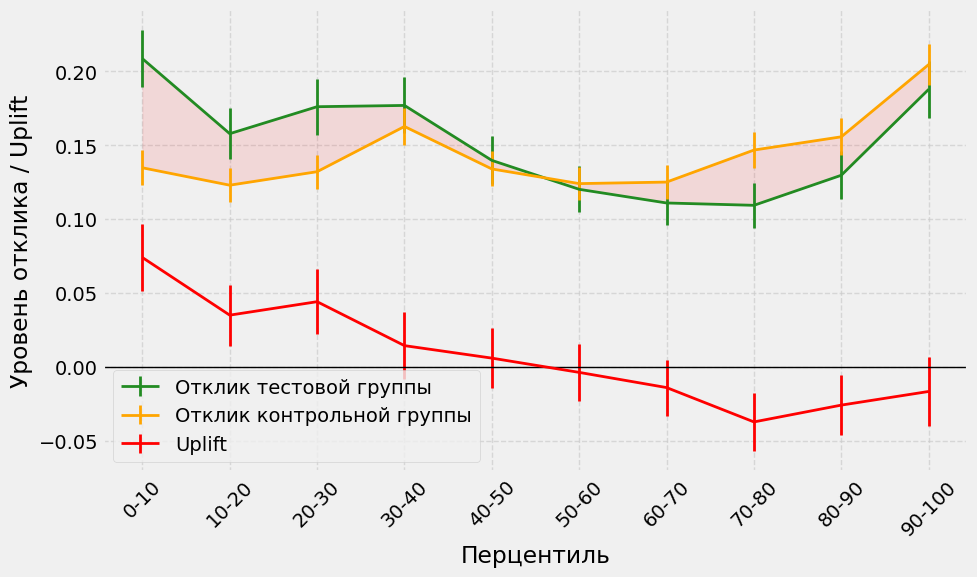

In [27]:
from utils import custom_uplift_by_percentile

custom_uplift_by_percentile(y_true=y_test,uplift=uplift_pred_test, treatment=treatment_test)
plt.show()

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [28]:
class UpliftModelInference:

    def __init__(self, model, feature_names, logger=None, categorical_cols=None, ohe_feature_columns=None):
        self.model = model
        self.feature_names = list(feature_names)
        self.logger = logger

        self.categorical_cols = list(categorical_cols) if categorical_cols is not None else []
        self.ohe_feature_columns = list(ohe_feature_columns) if ohe_feature_columns is not None else None

        if self.logger:
            self.logger.info(f"uplift model initialized, features: {self.feature_names}")
            if self.ohe_feature_columns is not None:
                self.logger.info(f"ohe enabled, ohe columns count: {len(self.ohe_feature_columns)}")

    def _transform_data(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.logger:
            self.logger.debug(f"input shape before transform: {X.shape}")

        X_prepared = X[self.feature_names].copy()
        X_prepared = add_feature_engineering(X_prepared)

        if self.ohe_feature_columns is None or not self.categorical_cols:
            return X_prepared

        X_encoded = pd.get_dummies(X_prepared, columns=self.categorical_cols)
        X_encoded = X_encoded.reindex(columns=self.ohe_feature_columns, fill_value=0)

        if self.logger:
            self.logger.debug(f"input shape after ohe: {X_encoded.shape}")

        return X_encoded

    def predict(self, X: pd.DataFrame):
        if X is None or X.empty:
            if self.logger:
                self.logger.error("empty dataframe provided")
            return None

        if X.isnull().any().any():
            if self.logger:
                self.logger.error("input contains missing values")
            return [None] * len(X)

        missing_features = sorted(set(self.feature_names) - set(X.columns))
        if missing_features:
            error_msg = f"missing features: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)
            return [None] * len(X)

        if self.logger:
            self.logger.info(f"running prediction for shape: {X.shape}")

        X_transformed = self._transform_data(X)

        if self.logger:
            self.logger.debug("calling model.predict")

        uplift = np.asarray(self.model.predict(X_transformed.values)).squeeze()

        if self.logger:
            self.logger.info("prediction finished")

        return uplift

In [29]:
model = UpliftModelInference(
    model=x_learner_tuned,
    feature_names=feature_names,
    categorical_cols=categorical_features,
    ohe_feature_columns=ohe_feature_columns
)

In [30]:
test_data = pd.DataFrame({
    'recency': [1, 2, 3],
    'history_segment': [1, 2, 3], 
    'history': [100, 200, 300],
    'mens': [1, 0, 1],
    'womens': [0, 1, 0],
    'zip_code': [1, 0, 1],
    'newbie': [0, 1, 0],
    'channel': [1, 2, 0]
})

In [31]:
pred = model.predict(test_data)
print("inference uplift:", pred)

inference uplift: [-0.01156892 -0.01043485 -0.05129193]
